In [25]:
# ============================================================
# IMPORTATION ET PRETRAITEMENT
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Charger le fichier
df = pd.read_excel("ussuperstoredata.xls")


print(df.shape)
print(df.head())

# Informations générales
print(df.info())

# Valeurs manquantes
print(df.isnull().sum())

# Conversion des dates
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

# Vérification
print(df.describe())

(9994, 21)
   Row ID        Order ID Order Date  Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
1       2  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
2       3  CA-2016-138688 2016-06-12 2016-06-16    Second Class    DV-13045   
3       4  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   
4       5  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   South

State
California      457687.6315
New York        310876.2710
Texas           170188.0458
Washington      138641.2700
Pennsylvania    116511.9140
Florida          89473.7080
Illinois         80166.1010
Ohio             78258.1360
Michigan         76269.6140
Virginia         70636.7200
Name: Sales, dtype: float64


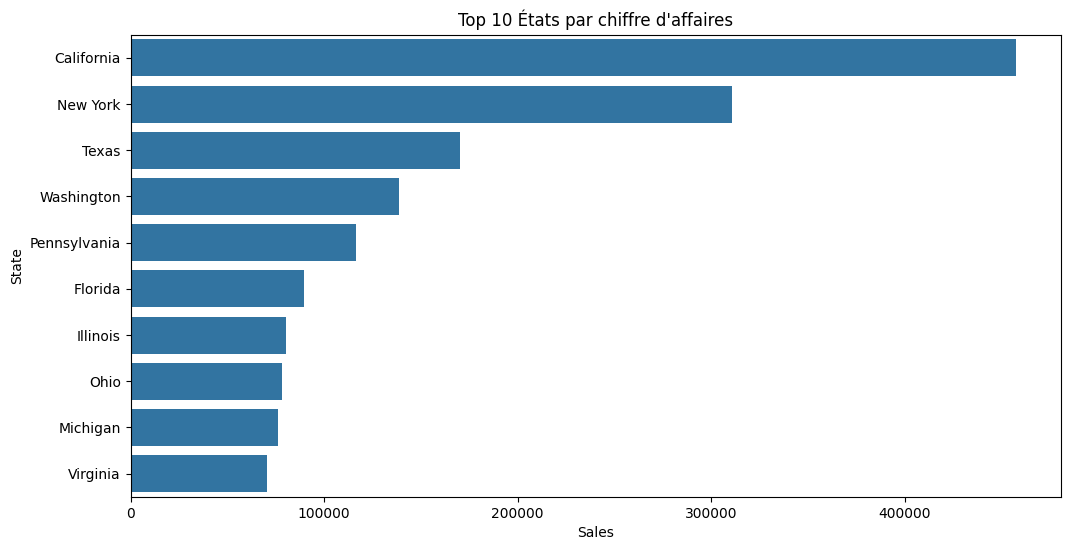

In [26]:
# ============================================================
# ETATS AYANT LE PLUS DE VENTES
# ============================================================

state_sales = (
    df.groupby("State")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

print(state_sales.head(10))

plt.figure(figsize=(12,6))

sns.barplot(
    x=state_sales.head(10).values,
    y=state_sales.head(10).index
)

plt.title("Top 10 États par chiffre d'affaires")
plt.xlabel("Sales")
plt.show()

                  Sales      Profit
State                              
California  457687.6315  76381.3871
New York    310876.2710  74038.5486


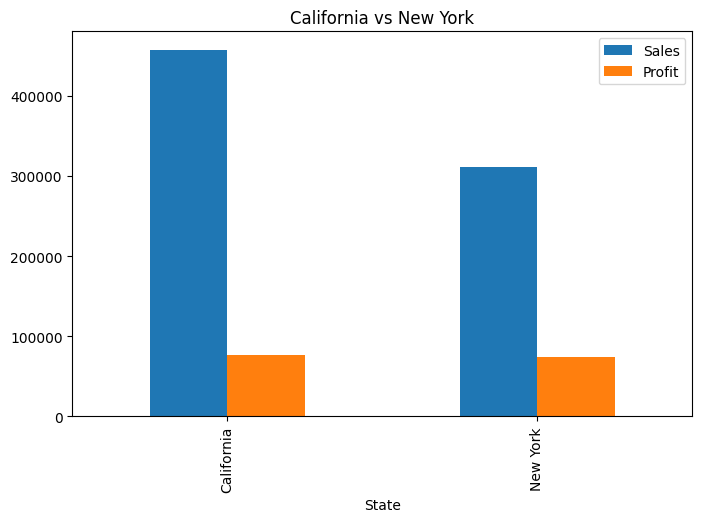

In [27]:
# ============================================================
# CALIFORNIE VS NEW YORK
# ============================================================

comparison = (
    df[df["State"].isin(["California","New York"])]
    .groupby("State")[["Sales","Profit"]]
    .sum()
)

print(comparison)

comparison.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("California vs New York")
plt.show()

In [28]:
# ============================================================
# CLIENT EXCEPTIONNEL A NEW YORK
# ============================================================

ny_customers = (
    df[df["State"]=="New York"]
    .groupby("Customer Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print(ny_customers.head(10))

Customer Name
Tom Ashbrook        13723.498
Peter Fuller         7678.228
Seth Vernon          7359.918
Tom Boeckenhauer     6999.960
Greg Tran            6712.744
Todd Sumrall         6492.314
Karen Daniels        6241.282
Keith Dawkins        5854.194
Luke Weiss           5048.186
Caroline Jumper      5012.760
Name: Sales, dtype: float64


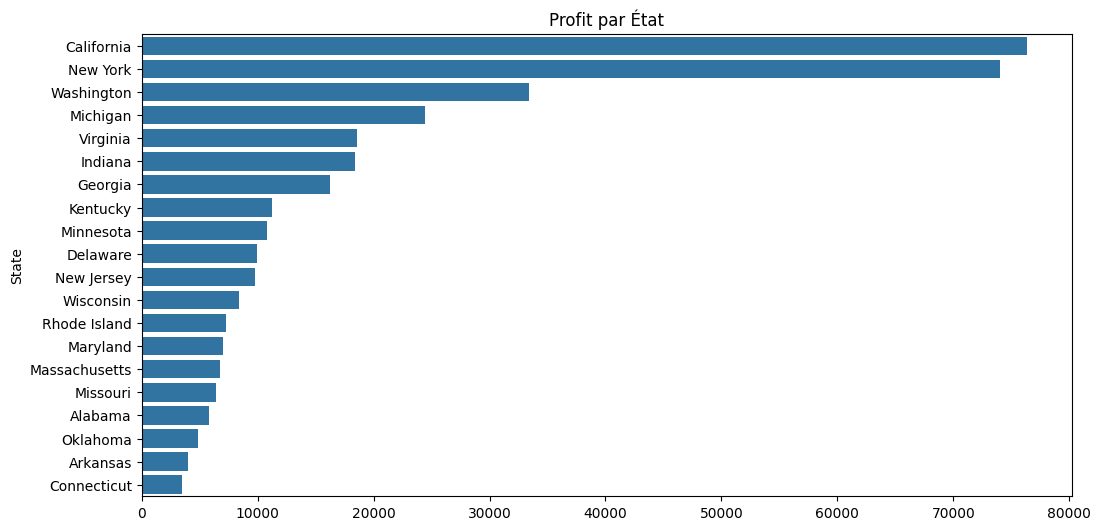

In [29]:
# ============================================================
# RENTABILITE PAR ETAT
# ============================================================

state_profit = (
    df.groupby("State")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=state_profit.head(20).values,
    y=state_profit.head(20).index
)

plt.title("Profit par État")
plt.show()

In [30]:
# ============================================================
# PARETO CLIENTS / PROFITS
# ============================================================

customer_profit = (
    df.groupby("Customer Name")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

cum_profit = customer_profit.cumsum()
cum_percent = cum_profit / customer_profit.sum() * 100

pareto_df = pd.DataFrame({
    "Profit": customer_profit,
    "CumPercent": cum_percent
})

print(pareto_df.head())

clients_80 = (cum_percent <= 80).sum()

print("Clients représentant 80% des profits :", clients_80)
print("Pourcentage clients :",
      round(clients_80/len(customer_profit)*100,2),"%")

                  Profit  CumPercent
Customer Name                       
Tamara Chand   8981.3239    3.135970
Raymond Buch   6976.0959    5.571783
Sanjit Chand   5757.4119    7.582073
Hunter Lopez   5622.4292    9.545232
Adrian Barton  5444.8055   11.446371
Clients représentant 80% des profits : 152
Pourcentage clients : 19.17 %


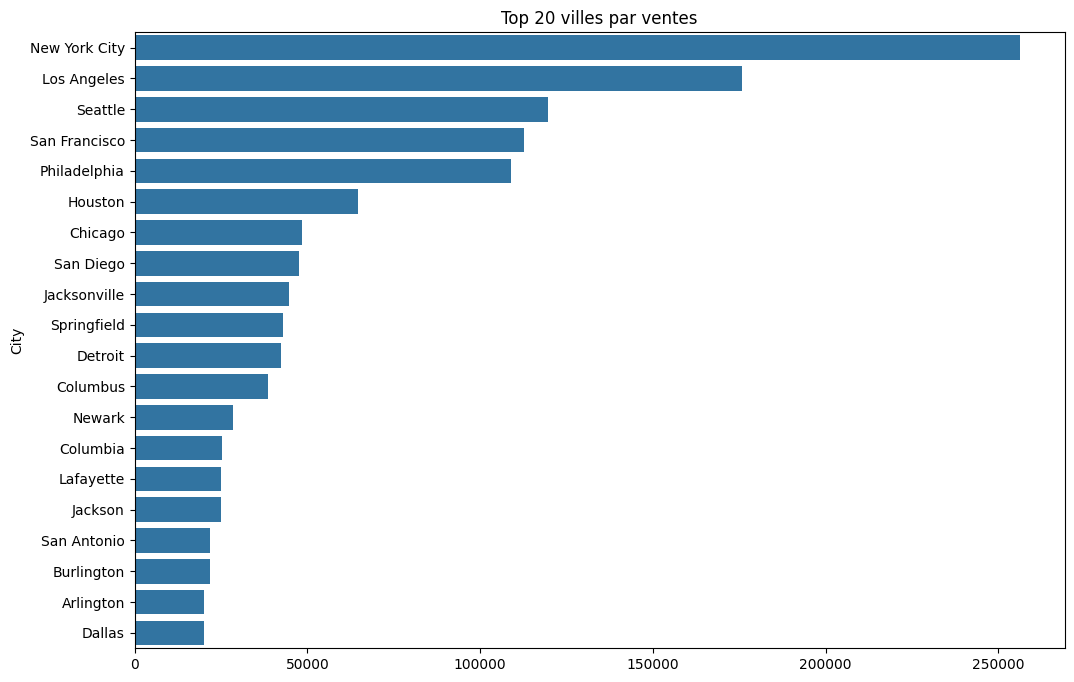

In [31]:
# ============================================================
# TOP 20 VILLES PAR VENTES
# ============================================================

city_sales = (
    df.groupby("City")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(20)
)

plt.figure(figsize=(12,8))

sns.barplot(
    x=city_sales.values,
    y=city_sales.index
)

plt.title("Top 20 villes par ventes")
plt.show()

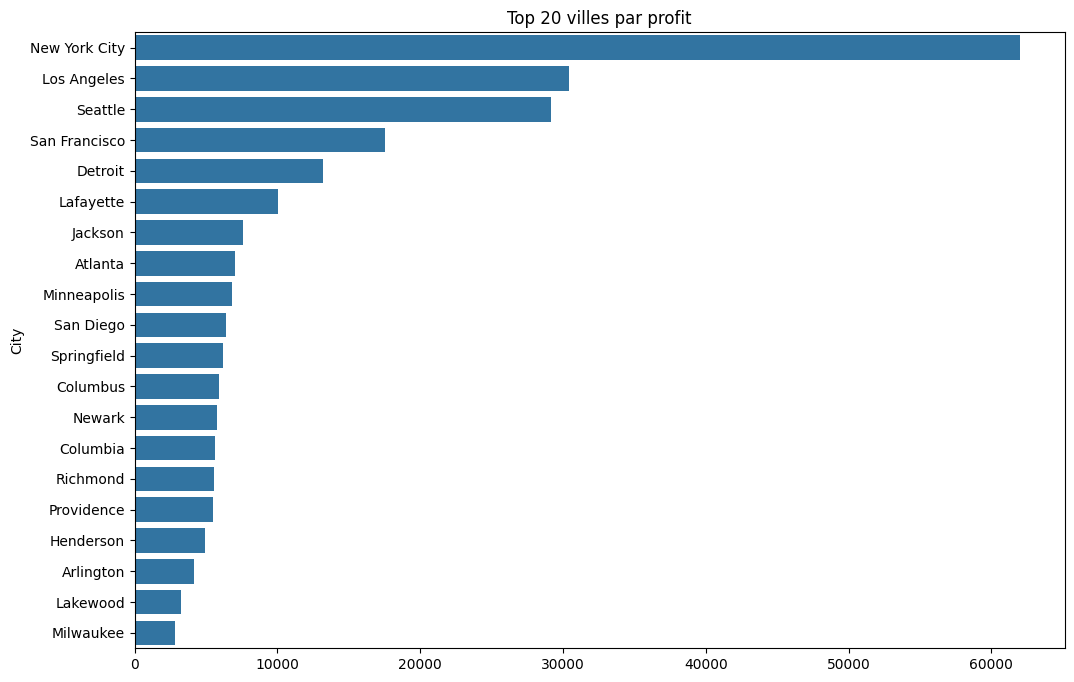

In [32]:
# ============================================================
# TOP 20 VILLES PAR PROFIT
# ============================================================

city_profit = (
    df.groupby("City")["Profit"]
      .sum()
      .sort_values(ascending=False)
      .head(20)
)

plt.figure(figsize=(12,8))

sns.barplot(
    x=city_profit.values,
    y=city_profit.index
)

plt.title("Top 20 villes par profit")
plt.show()

In [33]:
# ============================================================
# RENTABILITE DES VILLES
# ============================================================

city_analysis = (
    df.groupby("City")
      .agg({
          "Sales":"sum",
          "Profit":"sum"
      })
)

city_analysis["Profitability"] = (
    city_analysis["Profit"] /
    city_analysis["Sales"]
)

print(
    city_analysis.sort_values(
        "Profitability",
        ascending=False
    ).head(20)
)

                 Sales    Profit  Profitability
City                                           
Atlantic City   23.360   11.6800       0.500000
Grand Island    15.960    7.9800       0.500000
New Brunswick   14.770    7.1567       0.484543
Summerville    406.940  196.9132       0.483888
Holland        137.860   66.6588       0.483525
Antioch         19.440    9.3312       0.480000
Davis           32.400   15.5520       0.480000
Royal Oak       35.340   16.9632       0.480000
Lindenhurst     55.480   26.6304       0.480000
Bozeman         43.660   20.8106       0.476651
San Clemente    90.058   42.5419       0.472383
San Mateo       75.180   35.3346       0.470000
Layton           4.960    2.3312       0.470000
Hagerstown      43.800   20.5860       0.470000
Gulfport       166.500   77.5761       0.465923
East Orange    377.270  174.6191       0.462849
Norfolk         17.430    8.0178       0.460000
Rogers          40.410   18.5886       0.460000
Iowa City        9.990    4.4955       0

In [34]:
# ============================================================
# TOP 20 CLIENTS
# ============================================================

top_customers = (
    df.groupby("Customer Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(20)
)

print(top_customers)

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Todd Sumrall          11891.751
Greg Tran             11820.120
Becky Martin          11789.630
Seth Vernon           11470.950
Caroline Jumper       11164.974
Clay Ludtke           10880.546
Maria Etezadi         10663.728
Karen Ferguson        10604.266
Bill Shonely          10501.653
Edward Hooks          10310.880
Name: Sales, dtype: float64


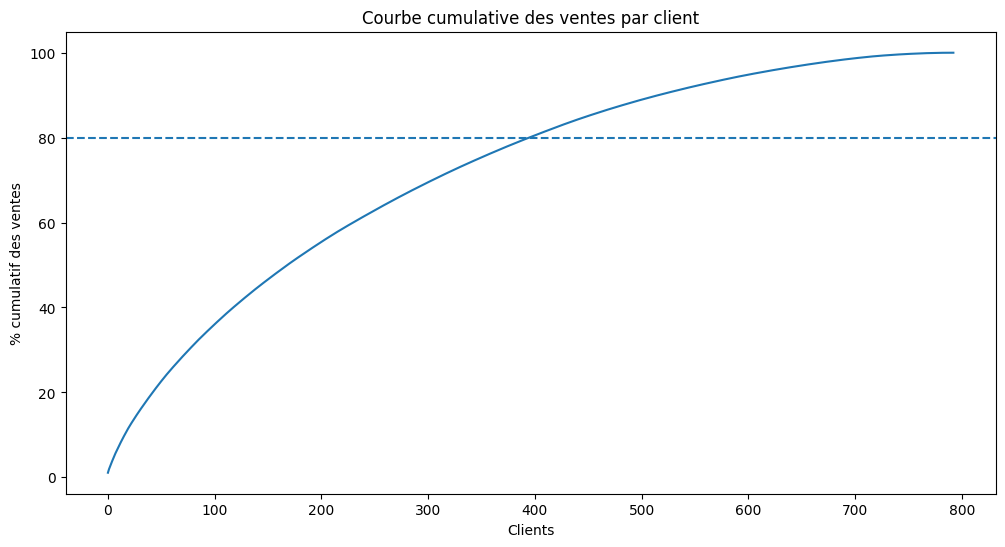

In [35]:
# ============================================================
# COURBE DE PARETO DES VENTES
# ============================================================

customer_sales = (
    df.groupby("Customer Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

cum_sales = customer_sales.cumsum()
cum_percent = cum_sales / customer_sales.sum() * 100

plt.figure(figsize=(12,6))

plt.plot(
    range(len(cum_percent)),
    cum_percent
)

plt.axhline(
    y=80,
    linestyle="--"
)

plt.title(
    "Courbe cumulative des ventes par client"
)

plt.xlabel("Clients")
plt.ylabel("% cumulatif des ventes")

plt.show()